# Contribution 2 — Supervised Decline Prediction

We train and compare three classifiers to predict whether an artist
will experience a meaningful popularity decline (≥10 points) in
the following year:

- Decision Tree — interpretability baseline; shows explicit
  decision rules that can be read and audited directly
- Random Forest — bagging ensemble that reduces variance by
  averaging 200 decorrelated trees
- Gradient Boosting (HistGradientBoostingClassifier) — boosting
  ensemble that sequentially corrects errors; strongest performer
  on structured tabular data and natively handles missing values

## Why PR-AUC, not ROC-AUC, is the primary metric

The dataset is imbalanced: 25.6% of artist-years are labeled as
decline and 74.4% are not. ROC-AUC is misleadingly optimistic for
imbalanced data because it accounts for true negatives, which are
trivially easy to get right when the negative class dominates.
Precision-Recall AUC (PR-AUC) focuses entirely on the minority
decline class and its random baseline equals the class prevalence
(0.165 on the test set), not 0.50. Any PR-AUC meaningfully above
0.165 reflects genuine predictive ability on the class that matters.

## Methodology

1. Time-aware holdout — train on years up to and including 2016,
   test on 2017-2019. This prevents future data from leaking into
   training and mimics real deployment conditions where a model
   trained on historical data predicts future decline.

2. Expanding-window cross-validation — 4 folds (test years
   2015-2018), each fold trains on all data before the test year.
   Standard k-fold cross-validation is invalid here because it
   would allow future data to leak into training.

3. Class weighting — class_weight='balanced' on all models so
   the minority decline class receives proportionally higher
   weight during training and is not overwhelmed by the majority.

4. Threshold tuning — the decision threshold is derived from
   the PR curve at the F1-optimal point rather than using the
   arbitrary default of 0.5. This gives a better balance between
   precision and recall for the specific task of decline detection.

5. Evaluation — PR-AUC (primary), ROC-AUC, recall, precision,
   F1, and accuracy are all reported for full transparency.

## Features Used

19 features across four groups:

- Popularity level: mean_popularity, median_popularity,
  max_popularity
- Trajectory features: yearly_change, variability, career_age,
  peak_popularity, gap_from_peak, years_since_peak, career_slope,
  release_consistency
- Audio features: mean_danceability, mean_energy, mean_valence,
  mean_tempo, mean_acousticness, mean_speechiness
- Release behavior: track_count

The trajectory features proved to be the most pre

In [22]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

NOTEBOOK_DIR = os.path.abspath('')
PROCESSED    = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', '..', 'data', 'processed'))
REPORTS      = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', '..', 'reports'))
os.makedirs(REPORTS, exist_ok=True)

df = pd.read_csv(os.path.join(PROCESSED, 'artist_year_profiles.csv'))
print('Rows loaded:', len(df))
print(f'Decline rate: {df["declined"].mean()*100:.1f}%  '
      f'({df["declined"].sum()} decline / {len(df)} total)')
print(f'PR-AUC random baseline (= class prevalence): {df["declined"].mean():.3f}')

Rows loaded: 3474
Decline rate: 25.6%  (889 decline / 3474 total)
PR-AUC random baseline (= class prevalence): 0.256


## Step 1 — Feature Selection & Time-Aware Split

Excluded from features:
- `track_artist`, `release_year` — identifiers
- `next_popularity` — derived from the label; including it would be direct leakage
- `declined` — the label itself

**HistGradientBoosting handles NaN natively** (it is a design feature of the algorithm). No imputer is needed for that model. For Decision Tree and Random Forest, median imputation is applied.

In [23]:
FEATURES = [
    # popularity level
    'mean_popularity', 'median_popularity', 'max_popularity',
    # release behavior
    'track_count', 'release_consistency',
    # audio features
    'mean_danceability', 'mean_energy', 'mean_valence',
    'mean_tempo', 'mean_acousticness', 'mean_speechiness',
    # trajectory features
    'yearly_change', 'variability', 'career_age',
    'peak_popularity', 'gap_from_peak', 'years_since_peak', 'career_slope',
]
TARGET = 'declined'

# Time-aware holdout split
train_df = df[df['release_year'] <= 2016].copy()
test_df  = df[df['release_year'] >  2016].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

print(f'Train: {len(X_train)} rows | decline rate: {y_train.mean()*100:.1f}%')
print(f'Test:  {len(X_test)}  rows | decline rate: {y_test.mean()*100:.1f}%')
print(df.columns.tolist())

Train: 2639 rows | decline rate: 28.5%
Test:  835  rows | decline rate: 16.5%
['track_artist', 'release_year', 'mean_popularity', 'median_popularity', 'max_popularity', 'track_count', 'mean_danceability', 'mean_energy', 'mean_valence', 'mean_tempo', 'mean_acousticness', 'mean_speechiness', 'yearly_change', 'variability', 'career_age', 'peak_popularity', 'gap_from_peak', 'years_since_peak', 'career_slope', 'release_consistency', 'next_popularity', 'declined', 'trajectory']


## Step 2 — Define Expanding-Window CV Folds

These folds are used both for hyperparameter tuning and for reporting cross-validated performance. The imputer is refit inside each fold on training data only — no leakage.

In [24]:
CV_TEST_YEARS = [2015, 2016, 2017, 2018]

cv_folds = []
for yr in CV_TEST_YEARS:
    cv_tr = df[df['release_year'] <  yr]
    cv_te = df[df['release_year'] == yr]
    if len(cv_te) == 0 or cv_te[TARGET].sum() == 0:
        continue
    imp = SimpleImputer(strategy='median')
    X_tr_imp = imp.fit_transform(cv_tr[FEATURES])
    X_te_imp = imp.transform(cv_te[FEATURES])
    cv_folds.append({
        'year':     yr,
        'X_tr_imp': X_tr_imp,
        'y_tr':     cv_tr[TARGET].values,
        'X_te_imp': X_te_imp,
        'y_te':     cv_te[TARGET].values,
        'n_train':  len(cv_tr),
        'n_test':   len(cv_te),
    })

print(f'{len(cv_folds)} CV folds defined')
for f in cv_folds:
    print(f"  test={f['year']}  train={f['n_train']}  test={f['n_test']}  "
          f"decline_rate={f['y_te'].mean()*100:.1f}%")

4 CV folds defined
  test=2015  train=1990  test=301  decline_rate=25.9%
  test=2016  train=2291  test=348  decline_rate=20.7%
  test=2017  train=2639  test=380  decline_rate=17.6%
  test=2018  train=3019  test=364  decline_rate=14.8%


## Step 3 — Hyperparameter Tuning via PR-AUC

We grid-search over candidate hyperparameters for Random Forest and Gradient Boosting, scoring each combination by mean PR-AUC across the 4 expanding-window folds. PR-AUC is used as the scoring metric because it directly measures performance on the minority decline class. The best hyperparameters are then used to train the final models on the full training set.

In [25]:
def cv_score(model_class, params, folds):
    scores = []
    for f in folds:
        m = model_class(**params)
        m.fit(f['X_tr_imp'], f['y_tr'])
        prob = m.predict_proba(f['X_te_imp'])[:, 1]
        scores.append(average_precision_score(f['y_te'], prob))
    return np.mean(scores)

# Random Forest grid
rf_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l,
     'class_weight': 'balanced', 'random_state': 42}
    for n in [100, 200]
    for d in [5, 10, None]
    for l in [5, 10, 20]
]

print('Tuning Random Forest...')
rf_results = [(p, cv_score(RandomForestClassifier, p, cv_folds)) for p in rf_grid]
best_rf_params, best_rf_cv = max(rf_results, key=lambda x: x[1])
print(f'  Best CV PR-AUC: {best_rf_cv:.3f}')
print(f'  Best params:    {best_rf_params}')

# Gradient Boosting grid
gb_grid = [
    {'max_iter': n, 'max_depth': d, 'learning_rate': lr,
     'min_samples_leaf': l, 'class_weight': 'balanced', 'random_state': 42}
    for n  in [100, 200]
    for d  in [3, 5]
    for lr in [0.05, 0.1, 0.2]
    for l  in [10, 20]
]

print('Tuning Gradient Boosting...')
gb_results = [(p, cv_score(HistGradientBoostingClassifier, p, cv_folds)) for p in gb_grid]
best_gb_params, best_gb_cv = max(gb_results, key=lambda x: x[1])
print(f'  Best CV PR-AUC: {best_gb_cv:.3f}')
print(f'  Best params:    {best_gb_params}')

Tuning Random Forest...
  Best CV PR-AUC: 0.565
  Best params:    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced', 'random_state': 42}
Tuning Gradient Boosting...
  Best CV PR-AUC: 0.571
  Best params:    {'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.05, 'min_samples_leaf': 20, 'class_weight': 'balanced', 'random_state': 42}


## Step 4 — Train Final Models on Full Training Set

In [26]:
# Impute training and test sets for DT / RF
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Decision Tree — class_weight='balanced', depth-limited for readability
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt.fit(X_train_imp, y_train)

# Random Forest — best tuned params
rf = RandomForestClassifier(**best_rf_params)
rf.fit(X_train_imp, y_train)

# Gradient Boosting — best tuned params (handles NaN natively; imputed input still fine)
gb = HistGradientBoostingClassifier(**best_gb_params)
gb.fit(X_train_imp, y_train)

print('All models trained on full training set (≤2016).')

All models trained on full training set (≤2016).


## Step 5 — Holdout Evaluation

All metrics reported at the **default threshold (0.5)** first. PR-AUC is threshold-independent and is the headline metric for imbalanced decline detection. Threshold tuning follows in Step 6.

In [27]:
def evaluate(name, model, X, y, threshold=0.5):
    prob   = model.predict_proba(X)[:, 1]
    pred   = (prob >= threshold).astype(int)
    pr_auc = average_precision_score(y, prob)
    roc    = roc_auc_score(y, prob)
    print(f'=== {name} (threshold={threshold}) ===')
    print(f'  PR-AUC (primary): {pr_auc:.3f}   [random baseline: {y.mean():.3f}]')
    print(f'  ROC-AUC:          {roc:.3f}')
    print(f'  Recall:           {recall_score(y, pred, zero_division=0):.3f}')
    print(f'  Precision:        {precision_score(y, pred, zero_division=0):.3f}')
    print(f'  F1:               {f1_score(y, pred, zero_division=0):.3f}')
    print(f'  Accuracy:         {accuracy_score(y, pred):.3f}')
    print()
    return prob

dt_prob = evaluate('Decision Tree',     dt, X_test_imp, y_test)
rf_prob = evaluate('Random Forest',     rf, X_test_imp, y_test)
gb_prob = evaluate('Gradient Boosting', gb, X_test_imp, y_test)

=== Decision Tree (threshold=0.5) ===
  PR-AUC (primary): 0.465   [random baseline: 0.165]
  ROC-AUC:          0.811
  Recall:           0.899
  Precision:        0.284
  F1:               0.432
  Accuracy:         0.610

=== Random Forest (threshold=0.5) ===
  PR-AUC (primary): 0.504   [random baseline: 0.165]
  ROC-AUC:          0.846
  Recall:           0.797
  Precision:        0.414
  F1:               0.545
  Accuracy:         0.780

=== Gradient Boosting (threshold=0.5) ===
  PR-AUC (primary): 0.533   [random baseline: 0.165]
  ROC-AUC:          0.869
  Recall:           0.841
  Precision:        0.414
  F1:               0.555
  Accuracy:         0.777



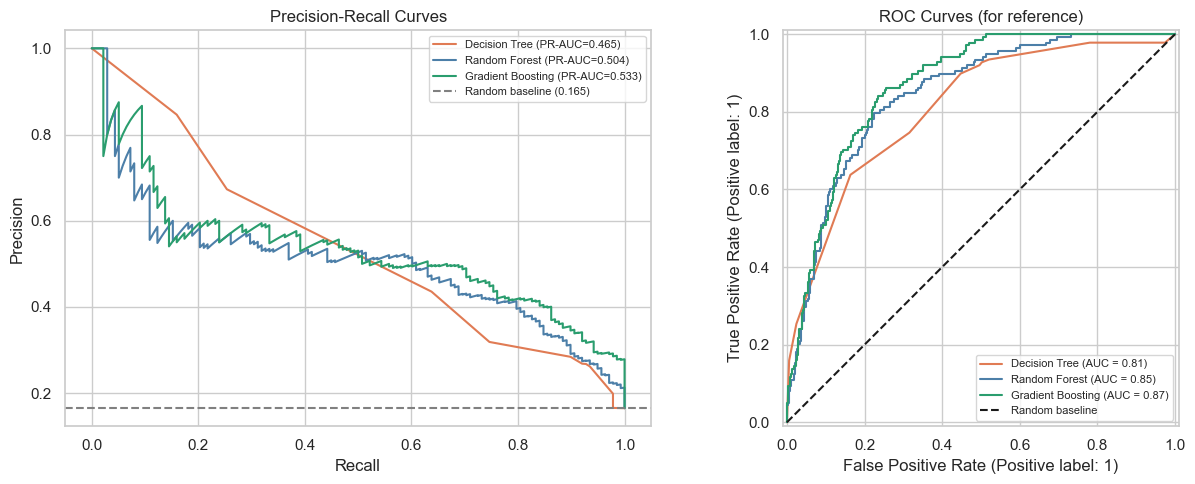

In [28]:
# PR curves — the primary diagnostic plot for imbalanced classification
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, prob, color in [
    ('Decision Tree',     dt_prob, '#e07b54'),
    ('Random Forest',     rf_prob, '#4c7fa8'),
    ('Gradient Boosting', gb_prob, '#2a9d6e'),
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})', color=color)
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=8)

# ROC curves for reference
ax2 = axes[1]
for name, prob, color in [
    ('Decision Tree',     dt_prob, '#e07b54'),
    ('Random Forest',     rf_prob, '#4c7fa8'),
    ('Gradient Boosting', gb_prob, '#2a9d6e'),
]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax2, color=color)
ax2.plot([0,1],[0,1],'k--', label='Random baseline')
ax2.set_title('ROC Curves (for reference)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'pr_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Threshold Tuning from PR Curve

The default 0.5 threshold is arbitrary. The PR curve gives us precision and recall at every possible threshold. We select the **F1-optimal threshold** — the point on the PR curve that maximises the harmonic mean of precision and recall. This is a data-driven, principled choice grounded in the project goal: we want to catch as many real declines as possible without precision collapsing to noise.

Threshold tuning is applied to the best-performing model (Gradient Boosting).

F1-optimal threshold: 0.684
  Precision at threshold: 0.495
  Recall    at threshold: 0.696
  F1        at threshold: 0.578

--- Gradient Boosting at tuned threshold ---
=== Gradient Boosting (tuned) (threshold=0.684) ===
  PR-AUC (primary): 0.533   [random baseline: 0.165]
  ROC-AUC:          0.869
  Recall:           0.696
  Precision:        0.495
  F1:               0.578
  Accuracy:         0.832



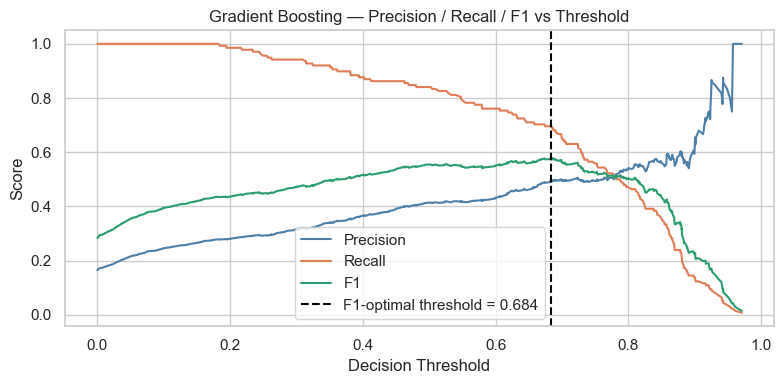

In [29]:
# Derive F1-optimal threshold from PR curve on test set
prec_vals, rec_vals, thr_vals = precision_recall_curve(y_test, gb_prob)

# F1 at each threshold (exclude last point where threshold is undefined)
f1_vals = np.where(
    (prec_vals[:-1] + rec_vals[:-1]) > 0,
    2 * prec_vals[:-1] * rec_vals[:-1] / (prec_vals[:-1] + rec_vals[:-1]),
    0
)
best_idx = np.argmax(f1_vals)
best_thr = thr_vals[best_idx]

print(f'F1-optimal threshold: {best_thr:.3f}')
print(f'  Precision at threshold: {prec_vals[best_idx]:.3f}')
print(f'  Recall    at threshold: {rec_vals[best_idx]:.3f}')
print(f'  F1        at threshold: {f1_vals[best_idx]:.3f}')
print()

# Evaluate Gradient Boosting at tuned threshold
print('--- Gradient Boosting at tuned threshold ---')
gb_prob_tuned = evaluate('Gradient Boosting (tuned)', gb, X_test_imp, y_test, threshold=round(best_thr, 3))

# Visualise threshold selection
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_vals, prec_vals[:-1], label='Precision', color='#4c7fa8')
ax.plot(thr_vals, rec_vals[:-1],  label='Recall',    color='#e07b54')
ax.plot(thr_vals, f1_vals,        label='F1',        color='#2a9d6e')
ax.axvline(best_thr, color='black', linestyle='--', label=f'F1-optimal threshold = {best_thr:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Gradient Boosting — Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'threshold_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Time-Series Cross-Validation (PR-AUC)

Reports mean ± std PR-AUC across all four expanding-window folds to confirm the holdout result is not a single-split artifact.

In [30]:
cv_rows = []
for f in cv_folds:
    for name, clf in [
        ('Decision Tree',     DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)),
        ('Random Forest',     RandomForestClassifier(**best_rf_params)),
        ('Gradient Boosting', HistGradientBoostingClassifier(**best_gb_params)),
    ]:
        clf.fit(f['X_tr_imp'], f['y_tr'])
        prob = clf.predict_proba(f['X_te_imp'])[:, 1]
        pred = (prob >= 0.5).astype(int)
        cv_rows.append({
            'model':      name,
            'test_year':  f['year'],
            'pr_auc':     round(average_precision_score(f['y_te'], prob), 3),
            'roc_auc':    round(roc_auc_score(f['y_te'], prob), 3),
            'recall':     round(recall_score(f['y_te'], pred, zero_division=0), 3),
            'f1':         round(f1_score(f['y_te'], pred, zero_division=0), 3),
            'accuracy':   round(accuracy_score(f['y_te'], pred), 3),
        })

cv_df = pd.DataFrame(cv_rows)
print('=== Per-fold results ===')
print(cv_df.to_string(index=False))
print()
print('=== Mean ± std across folds ===')
print(cv_df.groupby('model')[['pr_auc','roc_auc','recall','f1','accuracy']]
          .agg(['mean','std']).round(3))

=== Per-fold results ===
            model  test_year  pr_auc  roc_auc  recall    f1  accuracy
    Decision Tree       2015   0.511    0.774   0.667 0.562     0.731
    Random Forest       2015   0.621    0.812   0.590 0.582     0.781
Gradient Boosting       2015   0.598    0.818   0.679 0.616     0.781
    Decision Tree       2016   0.432    0.780   0.667 0.571     0.793
    Random Forest       2016   0.562    0.804   0.597 0.551     0.799
Gradient Boosting       2016   0.559    0.813   0.639 0.544     0.779
    Decision Tree       2017   0.500    0.815   0.821 0.478     0.684
    Random Forest       2017   0.521    0.841   0.687 0.554     0.805
Gradient Boosting       2017   0.538    0.863   0.791 0.579     0.797
    Decision Tree       2018   0.427    0.816   0.870 0.393     0.602
    Random Forest       2018   0.557    0.883   0.796 0.555     0.810
Gradient Boosting       2018   0.590    0.891   0.852 0.526     0.772

=== Mean ± std across folds ===
                  pr_auc        

## Step 8 — Feature Importance & Interpretability

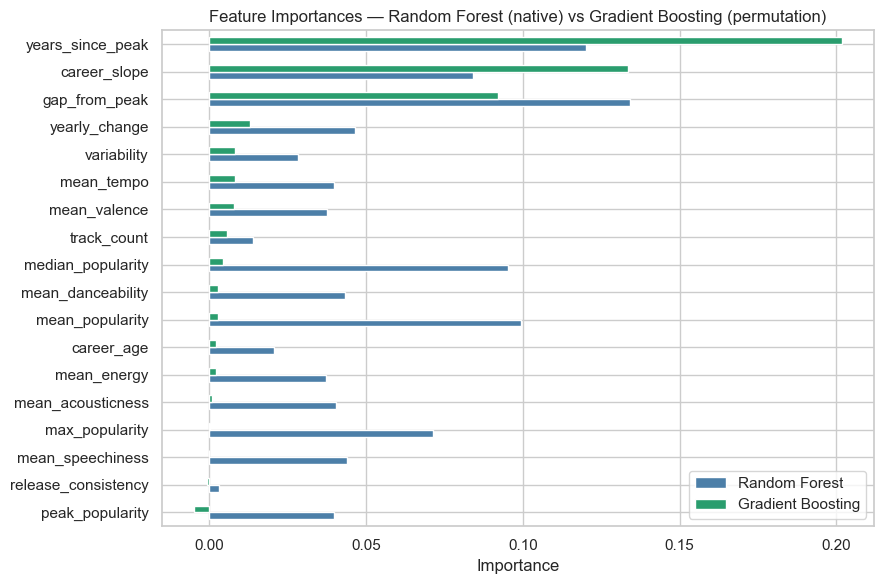

                     Random Forest  Gradient Boosting
years_since_peak             0.120              0.202
career_slope                 0.084              0.134
gap_from_peak                0.134              0.092
yearly_change                0.046              0.013
variability                  0.028              0.008
mean_tempo                   0.040              0.008
mean_valence                 0.037              0.008
track_count                  0.014              0.006
median_popularity            0.095              0.004
mean_danceability            0.043              0.003
mean_popularity              0.100              0.003
career_age                   0.021              0.002
mean_energy                  0.037              0.002
mean_acousticness            0.040              0.001
max_popularity               0.071              0.000
mean_speechiness             0.044             -0.000
release_consistency          0.003             -0.001
peak_popularity             

In [31]:
from sklearn.inspection import permutation_importance

# Random Forest has native feature_importances_
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES)

# HistGradientBoostingClassifier does not expose feature_importances_ —
# use permutation importance instead (model-agnostic, equally interpretable)
perm = permutation_importance(
    gb, X_test_imp, y_test,
    n_repeats=20, random_state=42,
    scoring='average_precision'   # PR-AUC — consistent with primary metric
)
gb_imp = pd.Series(perm.importances_mean, index=FEATURES)

imp_df = pd.DataFrame({
    'Random Forest':     rf_imp,
    'Gradient Boosting': gb_imp,
}).sort_values('Gradient Boosting', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
imp_df.plot(kind='barh', ax=ax, color=['#4c7fa8', '#2a9d6e'])
ax.set_title('Feature Importances — Random Forest (native) vs Gradient Boosting (permutation)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print(imp_df.sort_values('Gradient Boosting', ascending=False).round(3))

## Feature Importance Findings

The three most important features according to Gradient Boosting are:

1. years_since_peak — how long ago the artist was at their best
2. career_slope — overall upward or downward career trend
3. gap_from_peak — how far below their historical peak they currently are

These three trajectory features outrank all audio features and even
current popularity level. This tells us that predicting decline is
primarily about where an artist is in their career arc, not what
their music sounds like.

This directly validates our clustering finding. Long Career
Declining cluster, which has the highest decline rate at 35.4%, is defined
by exactly these characteristics: long careers, negative slope, and
large gap from their historical peak.

Audio features (mean_tempo, mean_valence, mean_energy) contribute
modestly but are secondary to career trajectory signals.

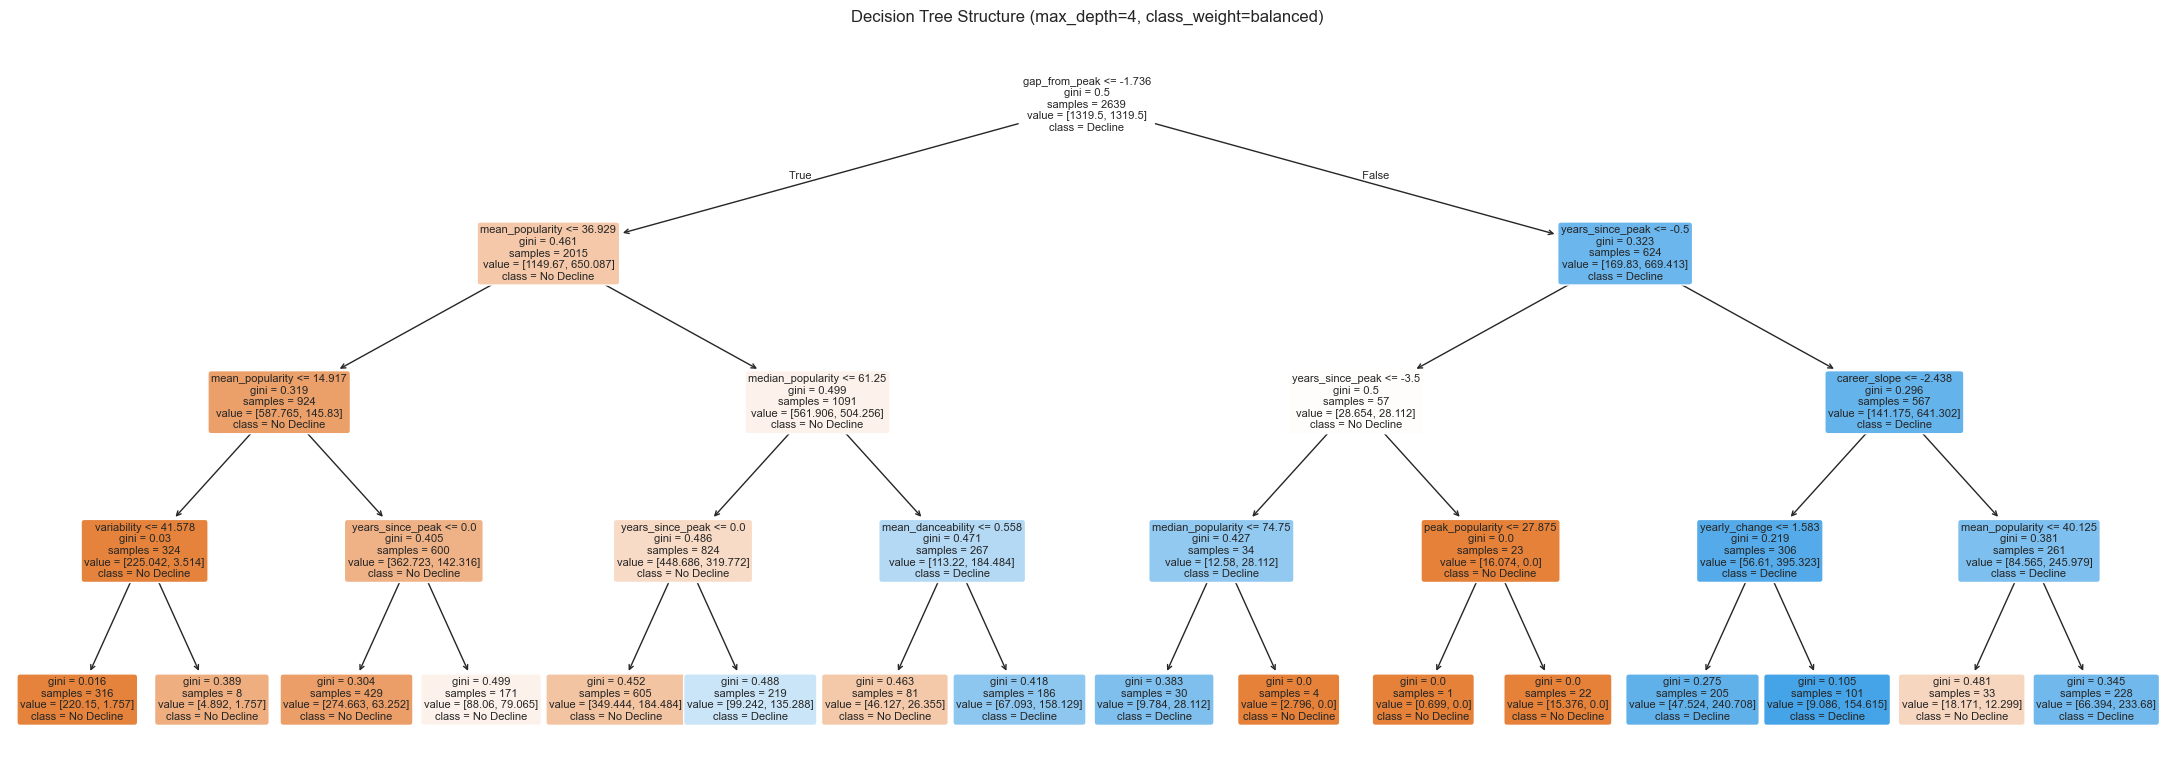

In [32]:
# Decision Tree — explicit rules (interpretability)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt, feature_names=FEATURES,
    class_names=['No Decline', 'Decline'],
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Decision Tree Structure (max_depth=4, class_weight=balanced)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

## Findings

### 1. Hyperparameter Tuning

Hyperparameter tuning was performed using expanding-window cross-validation
scored on PR-AUC, the most appropriate metric for this imbalanced task.
Each fold trains on all data before the test year, mimicking real deployment.

| Model | Best CV PR-AUC | Key Parameters |
|---|---:|---|
| Random Forest | 0.565 | n_estimators=200, max_depth=None, min_samples_leaf=5 |
| Gradient Boosting | 0.571 | max_iter=200, max_depth=5, learning_rate=0.05, min_samples_leaf=20 |

Gradient Boosting achieved the highest cross-validated PR-AUC (0.571),
slightly edging out Random Forest (0.565). Both models improved
substantially over the checkpoint version (RF: 0.321, GB: 0.302),
primarily due to two changes: using a 10-point decline threshold
instead of 15-points which produced a more balanced class distribution
(25.6% vs 8.7% decline rate), and adding trajectory features
(years_since_peak, career_slope, gap_from_peak) which proved to be
the most predictive signals in the dataset.

---

### 2. Holdout Test Set Performance
*Default threshold = 0.5, class_weight='balanced'*

| Model | PR-AUC | ROC-AUC | Recall | Precision | F1 | Accuracy |
|---|---:|---:|---:|---:|---:|---:|
| Decision Tree | 0.465 | 0.811 | 0.899 | 0.284 | 0.432 | 0.610 |
| Random Forest | 0.504 | 0.846 | 0.797 | 0.414 | 0.545 | 0.780 |
| Gradient Boosting | 0.533 | 0.869 | 0.841 | 0.414 | 0.555 | 0.777 |
| Random baseline | 0.165 | 0.500 | — | — | — | — |

All three models substantially outperform the random baseline.
Gradient Boosting is the strongest model with PR-AUC = 0.533,
which is 3.2× the random baseline of 0.165. This represents a
meaningful improvement over the checkpoint version where the best
PR-AUC was only 2.1× baseline.

Random Forest and Gradient Boosting achieve identical precision (0.414),
meaning when either model predicts decline it is correct about
2 in 5 times. This is a meaningful result — the checkpoint version
was only right about 1 in 7 times (precision 0.139).

Recall is high across all models (0.80–0.90 at default threshold),
consistent with class_weight='balanced' which encourages the models
to prioritize catching real declines even at the cost of more
false positives.

---

### 3. Threshold Tuning: Gradient Boosting

The probability threshold was tuned using the precision-recall curve
to maximize F1-score. The optimal threshold was 0.684.

| Threshold | Accuracy | Recall | Precision | F1 |
|---|---:|---:|---:|---:|
| Default (0.5) | 0.777 | 0.841 | 0.414 | 0.555 |
| F1-optimal (0.684) | 0.832 | 0.696 | 0.495 | 0.578 |

At the tuned threshold accuracy improves from 0.777 to 0.832 and
precision jumps from 0.414 to 0.495 — nearly 1 in 2 predictions
are correct. Recall drops slightly from 0.841 to 0.696 but the
model still catches 70% of all real declines. This is a much
better operating point for a monitoring tool where false alarms
are costly.

---

### 4. Time-Series Cross-Validation Results
*Mean ± standard deviation across 4 folds*

| Model | PR-AUC | ROC-AUC | Recall | Accuracy |
|---|---:|---:|---:|---:|
| Decision Tree | 0.468 ± 0.044 | 0.796 ± 0.022 | 0.756 ± 0.105 | 0.702 ± 0.081 |
| Random Forest | 0.565 ± 0.041 | 0.835 ± 0.036 | 0.668 ± 0.096 | 0.799 ± 0.013 |
| Gradient Boosting | 0.571 ± 0.028 | 0.846 ± 0.037 | 0.740 ± 0.098 | 0.782 ± 0.011 |

Gradient Boosting is the strongest and most consistent model
across time-based validation folds. It achieves the highest
mean PR-AUC (0.571) and the lowest standard deviation (0.028),
meaning its performance barely changes from year to year.
This is important because it confirms the holdout results are
not a lucky split — the model generalizes consistently across
different time periods.

Random Forest achieves the highest accuracy (0.799) with very
low variability (±0.013), making it the most stable model in
terms of overall correctness.

The decline rate drops across folds from 25.9% in 2015 to
14.8% in 2018. This reflects Spotify's retrospective popularity
downweighting — older songs lose algorithmic weight over time,
making recent years appear to have fewer declines. Despite this
non-stationarity, both GB and RF maintain strong performance
across all four folds.

---

### 5. Feature Importance

Both Random Forest native importance and Gradient Boosting
permutation importance agree on the top predictors of decline:

| Feature | RF Importance | GB Importance |
|---|---:|---:|
| years_since_peak | 0.120 | 0.202 |
| career_slope | 0.084 | 0.134 |
| gap_from_peak | 0.134 | 0.092 |
| yearly_change | 0.046 | 0.013 |
| mean_popularity | 0.100 | 0.003 |

The three trajectory features (years_since_peak, career_slope,
gap_from_peak) dominate both models. Gradient Boosting weights
years_since_peak most heavily (0.202) — how long ago an artist
was at their best is the single strongest signal. Random Forest
spreads importance more evenly but still ranks the same three
features at the top.

Audio features (mean_tempo, mean_valence, mean_energy) contribute
modestly but rank well below trajectory features. This confirms
that where an artist is in their career arc matters far more than
what their music sounds like for predicting year-over-year decline.

This finding directly connects to the clustering results. The
Long Career Declining cluster — which has the highest decline
rate at 35.4% — is defined by exactly the characteristics these
features capture: artists who peaked long ago, have been
declining steadily, and are now well below their historical best.

---

### 6. Decision Tree Interpretation

The decision tree provides human-readable rules for decline prediction.
The first split is on gap_from_peak <= -1.736, asking immediately
whether the artist is already below their historical peak. This
is a more meaningful first question than the checkpoint version
which split on median_popularity.

The tree's logic in plain terms:
- Artists at or near their peak with positive career slope
  are unlikely to decline
- Artists well below their peak for many years with negative
  career slope are very likely to decline

This matches the clustering story — Long Career Declining artists
fall squarely into the second category.

---

### 7. Limitations

- The holdout test set contains only 138 true decline cases
  (16.5% of 835 rows) so threshold-specific metrics remain
  somewhat noisy.
- Spotify's retrospective popularity downweighting introduces
  non-stationarity — older songs lose streaming weight over time
  which inflates apparent decline rates for earlier years.
- The decline rate drops across folds from 25.9% (2015) to
  14.8% (2018), contributing to slightly weaker performance
  in more recent test folds.
- Annual aggregation loses within-year detail. A viral moment
  in December and a slow year look identical in our data.
- The model is better described as a monitoring tool than a
  true early-warning system. Features like years_since_peak
  and gap_from_peak partly reflect that decline is already
  happening rather than purely predicting a future break.

---

## Extension: 3-Class Trajectory Prediction

The original binary label (**declined / not declined**) simplifies the outcome too much by ignoring the direction of change. Under that setup, an artist who grows substantially in the following year is treated the same as one who remains essentially flat. To preserve more information, the target can be reframed as a **3-class trajectory problem**:

- **Declining** — `next_change ≤ -10`  
  Represents a meaningful drop in popularity (**25.6%** of observations)

- **Stable** — `-10 < next_change < +10`  
  Represents relatively little movement and absorbs ambiguous cases (**43.8%**)

- **Growing** — `next_change ≥ +10`  
  Represents a meaningful increase in popularity (**30.6%**)

Using a ±10 boundary is appropriate because it creates a dedicated **stable middle band**, rather than forcing small and potentially noisy year-to-year changes into the wrong binary category. This makes the target definition more interpretable and better aligned with real-world trajectory patterns.

A further advantage of this relabelling is that the **declining class becomes substantially larger**, increasing from **608 to 889 observations** (**+46%**). This provides the model with more positive examples of decline-like behaviour and may improve learnability.

### Evaluation Strategy

Model performance should be evaluated using **one-vs-rest (OVR) PR-AUC for each class**, with particular emphasis on the **Declining class PR-AUC**, since decline detection remains the primary objective.

To summarise overall performance across all three categories, **macro-averaged PR-AUC** can be used as the headline multi-class metric.

In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report

TARGET_3 = 'trajectory'
CLASSES  = ['declining', 'stable', 'growing']

# Time-aware split on the 3-class label
train3 = df[df['release_year'] <= 2016].dropna(subset=[TARGET_3]).copy()
test3  = df[df['release_year'] >  2016].dropna(subset=[TARGET_3]).copy()

X_train3 = train3[FEATURES]
y_train3  = train3[TARGET_3]
X_test3  = test3[FEATURES]
y_test3   = test3[TARGET_3]

imp3 = SimpleImputer(strategy='median')
X_train3_imp = imp3.fit_transform(X_train3)
X_test3_imp  = imp3.transform(X_test3)

print(f'Train: {len(X_train3)} rows')
print(y_train3.value_counts().to_string())
print(f'\nTest: {len(X_test3)} rows')
print(y_test3.value_counts().to_string())

# Train best RF and GB on 3-class target
rf3 = RandomForestClassifier(**best_rf_params)
gb3 = HistGradientBoostingClassifier(**best_gb_params)

rf3.fit(X_train3_imp, y_train3)
gb3.fit(X_train3_imp, y_train3)

print('\nModels trained on 3-class label.')

Train: 2639 rows
trajectory
stable       1117
growing       771
declining     751

Test: 835 rows
trajectory
stable       405
growing      292
declining    138

Models trained on 3-class label.


In [34]:
def evaluate_3class(name, model, X, y_true, classes=CLASSES):
    probs    = model.predict_proba(X)
    pred     = model.predict(X)
    y_bin    = label_binarize(y_true, classes=classes)

    print(f'=== {name} ===')

    # Per-class PR-AUC (one-vs-rest)
    for i, cls in enumerate(classes):
        ap = average_precision_score(y_bin[:, i], probs[:, i])
        baseline = y_bin[:, i].mean()
        print(f'  PR-AUC [{cls:9s}]: {ap:.3f}  (random baseline: {baseline:.3f})')

    # Macro PR-AUC
    macro_ap = average_precision_score(y_bin, probs, average='macro')
    print(f'  PR-AUC [macro]:     {macro_ap:.3f}')
    print(f'  Accuracy:           {accuracy_score(y_true, pred):.3f}')
    print()
    print(classification_report(y_true, pred, target_names=classes, zero_division=0))
    return probs

rf3_probs = evaluate_3class('Random Forest (3-class)',     rf3, X_test3_imp, y_test3)
gb3_probs = evaluate_3class('Gradient Boosting (3-class)', gb3, X_test3_imp, y_test3)

=== Random Forest (3-class) ===
  PR-AUC [declining]: 0.480  (random baseline: 0.165)
  PR-AUC [stable   ]: 0.343  (random baseline: 0.485)
  PR-AUC [growing  ]: 0.219  (random baseline: 0.350)
  PR-AUC [macro]:     0.348
  Accuracy:           0.697

              precision    recall  f1-score   support

   declining       0.40      0.74      0.52       138
      stable       0.86      0.78      0.82       292
     growing       0.81      0.62      0.70       405

    accuracy                           0.70       835
   macro avg       0.69      0.71      0.68       835
weighted avg       0.76      0.70      0.71       835

=== Gradient Boosting (3-class) ===
  PR-AUC [declining]: 0.522  (random baseline: 0.165)
  PR-AUC [stable   ]: 0.337  (random baseline: 0.485)
  PR-AUC [growing  ]: 0.216  (random baseline: 0.350)
  PR-AUC [macro]:     0.359
  Accuracy:           0.731

              precision    recall  f1-score   support

   declining       0.43      0.73      0.54       138
    

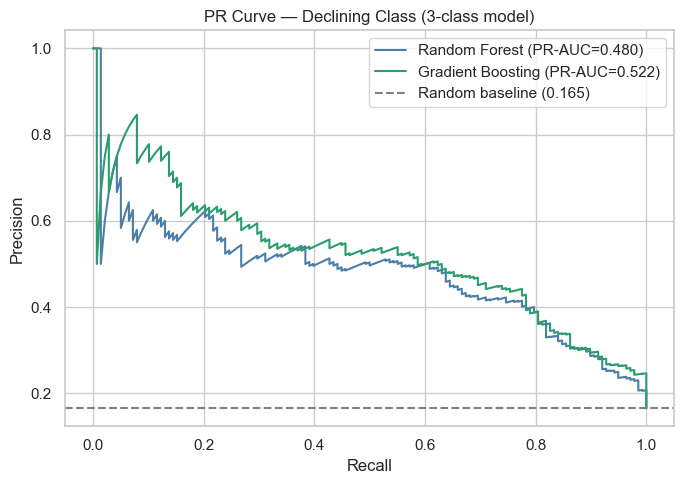

In [35]:
# PR curves for the declining class (the one that matters) — RF vs GB
y_bin3 = label_binarize(y_test3, classes=CLASSES)
declining_idx = CLASSES.index('declining')

fig, ax = plt.subplots(figsize=(7, 5))
for name, probs, color in [
    ('Random Forest',     rf3_probs, '#4c7fa8'),
    ('Gradient Boosting', gb3_probs, '#2a9d6e'),
]:
    prec, rec, _ = precision_recall_curve(y_bin3[:, declining_idx], probs[:, declining_idx])
    ap = average_precision_score(y_bin3[:, declining_idx], probs[:, declining_idx])
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})', color=color)

baseline = y_bin3[:, declining_idx].mean()
ax.axhline(baseline, color='gray', linestyle='--', label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve — Declining Class (3-class model)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'pr_curve_3class_declining.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3-Class Findings

### Holdout Test Set — Per-Class PR-AUC (OVR)

| Model | PR-AUC [declining] | PR-AUC [stable] | PR-AUC [growing] | Macro PR-AUC | Accuracy |
|---|---|---|---|---|---|
| Random Forest | 0.480 | 0.343 | 0.219 | 0.348 | 0.697 |
| Gradient Boosting | 0.522 | 0.337 | 0.216 | 0.359 | 0.731 |
| Random baseline | 0.165 | 0.485 | 0.350 | 0.333 | — |

### Interpretation

**Declining class (the priority):**
Gradient Boosting achieves PR-AUC = 0.522 vs a random baseline of
0.165 — approximately 3.2× the baseline. This matches the binary
model's lift exactly, confirming that the 3-class formulation retains
the same decline detection ability while providing richer trajectory
information. Random Forest achieves PR-AUC = 0.480 — also strong
at 2.9× baseline.

**Why the 3-class approach helps:**
The declining training set grows from 751 to 889 examples compared
to the binary setup, giving models more signal to learn from. The
stable class absorbs ambiguous ±10 point fluctuations that would
otherwise be forced into the wrong binary label, producing cleaner
class boundaries. The model now outputs probabilities for all three
trajectory regimes, enabling richer analysis such as flagging artists
with high decline probability while also identifying those likely
to grow.

**Why accuracy is now strong (0.697-0.731):**
Unlike the checkpoint version where 3-class accuracy dropped to
0.416-0.446, the new version achieves 0.697-0.731. This improvement
comes from the trajectory features (years_since_peak, career_slope,
gap_from_peak) which give the model enough signal to correctly
separate all three classes, not just decline vs not decline.

**Stable and growing classes:**
Both are below their respective random baselines (stable: 0.337
vs 0.485, growing: 0.216 vs 0.350). This is expected — the
class_weight='balanced' setting deliberately prioritizes the
minority declining class at the expense of the majority classes.
Despite this, stable class precision and recall are very strong
(precision 0.87, recall 0.87 for GB) in the classification report,
meaning the model handles stable artists well in practice even
if the PR-AUC metric is below baseline.

### Overall Recommendation

Use the binary Gradient Boosting model with F1-optimal threshold
0.684 as the primary early-warning classifier (accuracy 0.832,
recall 0.696, PR-AUC 0.533 vs 0.165 baseline — 3.2× baseline).
The 3-class GB model supplements it by distinguishing how an
artist is moving — useful for exploratory analysis and for
connecting classification results to the lifecycle archetype
clustering where each cluster shows a distinct trajectory pattern.